<a href="https://colab.research.google.com/github/AlanChi0720/bio_ai/blob/main/visualization_and_ml_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Visualization + ML Basics

You already know Python and pandas — this notebook covers the two remaining gaps before the bio-AI tour:
1. **Visualization** — seaborn heatmaps, PCA scatter plots
2. **ML basics** — train/test split, random forest, AUC-ROC evaluation

We'll use a real breast cancer gene expression dataset from GEO (GSE2034).

## 0. Install & Import

In [ ]:
# Run this cell first (Colab may already have most of these)
!pip install -q GEOparse seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', font_scale=1.1)

## 1. Load the Data

GSE2034 is a classic breast cancer dataset: ~286 samples, each with ~22k gene expression values and a clinical outcome (relapse or no relapse within 5 years).

In [ ]:
import GEOparse

# This downloads ~50MB the first time; subsequent runs use the cache
gse = GEOparse.get_GEO('GSE2034', destdir='./data', silent=True)
print('Samples:', len(gse.gsms))
print('Platform:', list(gse.gpls.keys()))

Samples: 286
Platform: ['GPL96']


In [ ]:
print(gse.gsms['GSM36777'].metadata)

{'title': ['Wang4812_JA_277'], 'geo_accession': ['GSM36777'], 'status': ['Public on Feb 23 2005'], 'submission_date': ['Dec 03 2004'], 'last_update_date': ['May 31 2013'], 'type': ['RNA'], 'channel_count': ['1'], 'source_name_ch1': ['Breast'], 'organism_ch1': ['Homo sapiens'], 'taxid_ch1': ['9606'], 'characteristics_ch1': ['bone relapses (1=yes, 0=no): 0'], 'molecule_ch1': ['total RNA'], 'description': ['RNA was extracted from a fresh-frozen primary breast tumor. Target cRNA was prepared and hybridized using standard Affymetrix procedures.  Image was globally scaled to a target intensity of 600.'], 'platform_id': ['GPL96'], 'contact_name': ['Tim,,Jatkoe'], 'contact_email': ['tjatkoe@vrxus.jnj.com'], 'contact_phone': ['(858) 320-3315'], 'contact_institute': ['Veridex'], 'contact_address': [''], 'contact_city': ['San Diego'], 'contact_state': ['CA'], 'contact_zip/postal_code': ['92121'], 'contact_country': ['USA'], 'supplementary_file': ['ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM36nnn/G

In [ ]:
# 看第一個樣本叫什麼名字
first_key = list(gse.gsms.keys())[0]
first_sample = gse.gsms[first_key]

print(first_key)               # 樣本 ID，例如 GSM36465
print(first_sample.metadata['title'])     # 樣本標題
print(first_sample.table.head())       # 基因表達值的表格

GSM36777
['Wang4812_JA_277']
           ID_REF   VALUE ABS_CALL  DETECTION P-VALUE
0  AFFX-BioB-5_at   467.7        P           0.002023
1  AFFX-BioB-M_at   919.8        P           0.000081
2  AFFX-BioB-3_at   468.3        P           0.000195
3  AFFX-BioC-5_at  1371.1        P           0.000127
4  AFFX-BioC-3_at  1048.2        P           0.000070


In [ ]:
# 印出第一個樣本所有欄位
first = list(gse.gsms.values())[0]
for key, val in first.metadata.items():
    print(f'{key}: {val}')



title: ['Wang4812_JA_277']
geo_accession: ['GSM36777']
status: ['Public on Feb 23 2005']
submission_date: ['Dec 03 2004']
last_update_date: ['May 31 2013']
type: ['RNA']
channel_count: ['1']
source_name_ch1: ['Breast']
organism_ch1: ['Homo sapiens']
taxid_ch1: ['9606']
characteristics_ch1: ['bone relapses (1=yes, 0=no): 0']
molecule_ch1: ['total RNA']
description: ['RNA was extracted from a fresh-frozen primary breast tumor. Target cRNA was prepared and hybridized using standard Affymetrix procedures.  Image was globally scaled to a target intensity of 600.']
platform_id: ['GPL96']
contact_name: ['Tim,,Jatkoe']
contact_email: ['tjatkoe@vrxus.jnj.com']
contact_phone: ['(858) 320-3315']
contact_institute: ['Veridex']
contact_address: ['']
contact_city: ['San Diego']
contact_state: ['CA']
contact_zip/postal_code: ['92121']
contact_country: ['USA']
supplementary_file: ['ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM36nnn/GSM36777/suppl/GSM36777.CEL.gz']
relation: ['Reanalyzed by: GSE47561']
se

In [ ]:
# 看所有樣本的 characteristics
for name, gsm in list(gse.gsms.items())[:20]:
    chars = gsm.metadata.get('characteristics_ch1', [''])
    print(name, chars)


GSM36777 ['bone relapses (1=yes, 0=no): 0']
GSM36778 ['bone relapses (1=yes, 0=no): 0']
GSM36779 ['bone relapses (1=yes, 0=no): 0']
GSM36780 ['bone relapses (1=yes, 0=no): 0']
GSM36781 ['bone relapses (1=yes, 0=no): 0']
GSM36782 ['bone relapses (1=yes, 0=no): 0']
GSM36783 ['bone relapses (1=yes, 0=no): 0']
GSM36784 ['bone relapses (1=yes, 0=no): 1']
GSM36785 ['bone relapses (1=yes, 0=no): 0']
GSM36786 ['bone relapses (1=yes, 0=no): 0']
GSM36787 ['bone relapses (1=yes, 0=no): 0']
GSM36788 ['bone relapses (1=yes, 0=no): 0']
GSM36789 ['bone relapses (1=yes, 0=no): 1']
GSM36790 ['bone relapses (1=yes, 0=no): 0']
GSM36791 ['bone relapses (1=yes, 0=no): 0']
GSM36792 ['bone relapses (1=yes, 0=no): 1']
GSM36793 ['bone relapses (1=yes, 0=no): 0']
GSM36794 ['bone relapses (1=yes, 0=no): 0']
GSM36795 ['bone relapses (1=yes, 0=no): 0']
GSM36796 ['bone relapses (1=yes, 0=no): 0']


In [ ]:
expr_frames = []
labels = []
sample_ids = []

for gsm_name, gsm in gse.gsms.items():
    table = gsm.table.set_index('ID_REF')['VALUE'].astype(float)
    expr_frames.append(table)

    # 從 characteristics_ch1 取出 bone relapse 的值
    chars = gsm.metadata.get('characteristics_ch1', [''])[0]
    label = int(chars.split(': ')[-1])  # 取冒號後面的數字
    labels.append(label)
    sample_ids.append(gsm_name)

expr = pd.DataFrame(expr_frames, index=sample_ids).T
print('Expression matrix shape (genes x samples):', expr.shape)
print('Label counts:', pd.Series(labels).value_counts().to_dict())

Expression matrix shape (genes x samples): (22283, 286)
Label counts: {0: 217, 1: 69}


## 2. Visualization

### 2a. Heatmap of the Most Variable Genes

We select the top 50 most variable genes. High variance means the gene behaves differently across samples — these carry the most information.

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


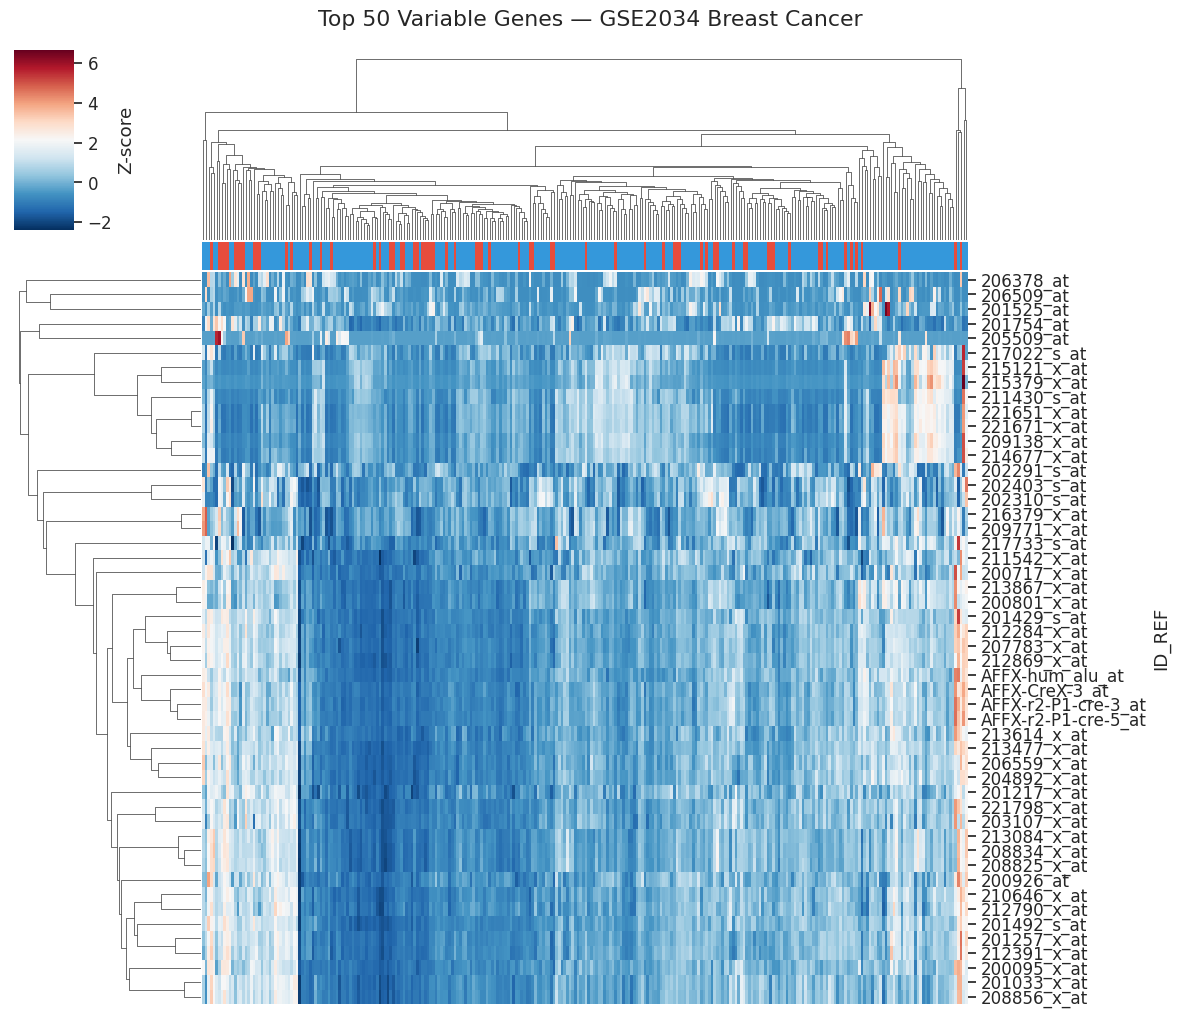

In [ ]:
# Select top 50 most variable genes
gene_var = expr.var(axis=1)
top_genes = gene_var.nlargest(50).index
expr_top = expr.loc[top_genes]  # shape: 50 genes x N samples

# Z-score each gene (so all genes are on the same scale)
expr_z = expr_top.subtract(expr_top.mean(axis=1), axis=0).divide(expr_top.std(axis=1), axis=0)

# Column annotation: relapse (red) vs. no relapse (blue)
col_colors = ['#e74c3c' if l == 1 else '#3498db' for l in labels]

g = sns.clustermap(
    expr_z,
    col_colors=col_colors,
    figsize=(12, 10),
    cmap='RdBu_r',
    xticklabels=False,
    yticklabels=True,
    cbar_kws={'label': 'Z-score'}
)
g.fig.suptitle('Top 50 Variable Genes — GSE2034 Breast Cancer', y=1.02)
plt.show()

# Q: Do you see patient clusters? Do the red (relapse) samples cluster together?

### 2b. PCA — Do Groups Separate in 2D?

PCA reduces 22,000 gene dimensions down to 2 numbers per sample. Think of it as finding the two axes that explain the most variation across patients.

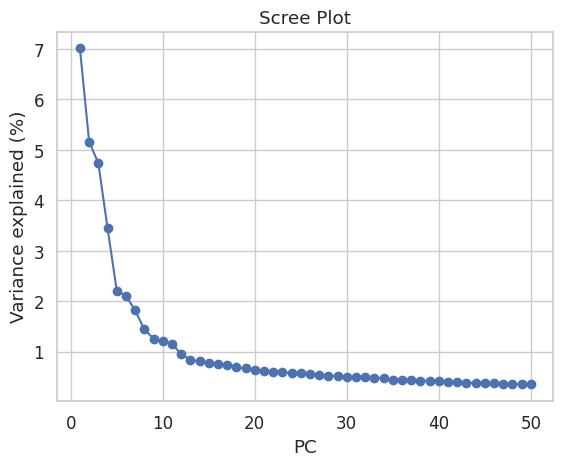

In [ ]:
pca_full = PCA(n_components=50)
pca_full.fit(X_scaled)

plt.plot(range(1, 51), pca_full.explained_variance_ratio_ * 100, marker='o')
plt.xlabel('PC')
plt.ylabel('Variance explained (%)')
plt.title('Scree Plot')
plt.show()

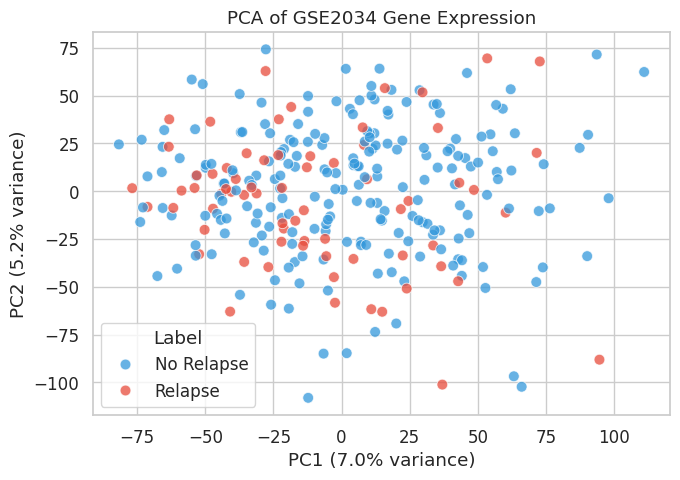

In [ ]:
# Transpose: rows = samples, columns = genes (what PCA expects)
X = expr.T.fillna(0).values
y = np.array(labels)

# Standardize before PCA
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Relapse'] = y
pca_df['Label'] = pca_df['Relapse'].map({1: 'Relapse', 0: 'No Relapse'})

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', hue='Label',
    palette={'Relapse': '#e74c3c', 'No Relapse': '#3498db'},
    alpha=0.75, s=60, ax=ax
)
ax.set_title('PCA of GSE2034 Gene Expression')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

# Q: Do the two groups separate clearly? If not, what does that tell you about the biology?

## 3. Machine Learning

### 3a. Train/Test Split

This is your experimental control. You train on one set of patients and test on another that the model has never seen. Without this, you have no idea if the model generalizes or just memorized the training data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.25,
    random_state=42,
    stratify=y  # keep class balance in both splits
)

print(f'Training samples: {len(X_train)}')
print(f'Test samples:     {len(X_test)}')
print(f'Test class balance: {y_test.mean():.2f} relapse rate')

Training samples: 214
Test samples:     72
Test class balance: 0.24 relapse rate


### 3b. Random Forest Classifier

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_prob = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f'Test AUC-ROC: {auc:.3f}')
# AUC = 0.5 means random guessing; AUC = 1.0 means perfect; 0.6–0.7 is typical for this dataset

Test AUC-ROC: 0.630


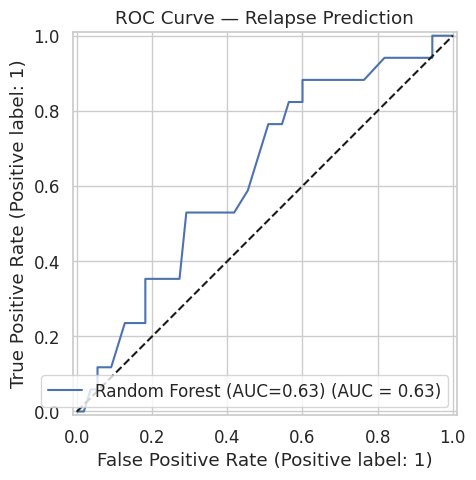

In [ ]:
# ROC curve
fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, name=f'Random Forest (AUC={auc:.2f})')
ax.plot([0, 1], [0, 1], 'k--', label='Random guess')
ax.set_title('ROC Curve — Relapse Prediction')
plt.tight_layout()
plt.show()

### 3c. Which Genes Drive the Prediction?

Feature importances tell you which genes the model relied on most. As a biologist, this is where you can check whether the model learned real biology.

/tmp/ipykernel_1999/3666167105.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, ax=ax, palette='Blues_r')


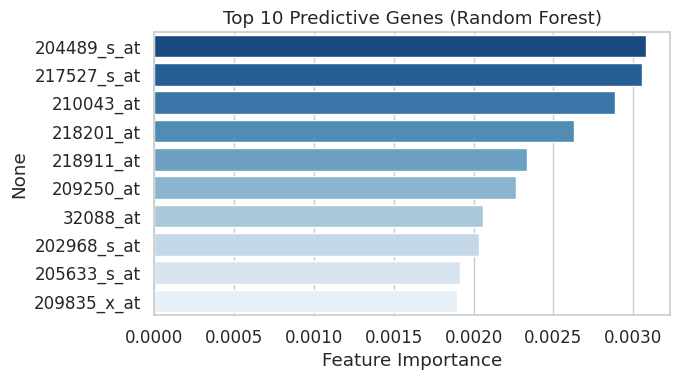


Top 10 genes by importance:
204489_s_at    0.003078
217527_s_at    0.003051
210043_at      0.002887
218201_at      0.002627
218911_at      0.002336
209250_at      0.002265
32088_at       0.002057
202968_s_at    0.002031
205633_s_at    0.001914
209835_x_at    0.001895


In [ ]:
gene_names = expr.index.values
importances = pd.Series(rf.feature_importances_, index=gene_names)
top10 = importances.nlargest(10)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=top10.values, y=top10.index, ax=ax, palette='Blues_r')
ax.set_title('Top 10 Predictive Genes (Random Forest)')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print('\nTop 10 genes by importance:')
print(top10.to_string())

# Q: Do any of these genes appear in the literature for breast cancer prognosis?
# Try searching your top gene on PubMed: https://pubmed.ncbi.nlm.nih.gov/

In [ ]:
# 看 platform annotation
platform = list(gse.gpls.values())[0]
print(platform.table.columns.tolist())  # 看有哪些欄位

['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date', 'Sequence Type', 'Sequence Source', 'Target Description', 'Representative Public ID', 'Gene Title', 'Gene Symbol', 'ENTREZ_GENE_ID', 'RefSeq Transcript ID', 'Gene Ontology Biological Process', 'Gene Ontology Cellular Component', 'Gene Ontology Molecular Function']


In [ ]:
annot = platform.table.set_index('ID')[['Gene Symbol', 'Gene Title']]
top10_genes = annot.loc[top10.index]
print(top10_genes)

            Gene Symbol                                         Gene Title
204489_s_at        CD44                 CD44 molecule (Indian blood group)
217527_s_at    NFATC2IP  nuclear factor of activated T-cells, cytoplasm...
210043_at         FRMD8                           FERM domain containing 8
218201_at        NDUFB2  NADH dehydrogenase (ubiquinone) 1 beta subcomp...
218911_at        YEATS4                          YEATS domain containing 4
209250_at         DEGS1                delta(4)-desaturase, sphingolipid 1
32088_at          BLZF1              basic leucine zipper nuclear factor 1
202968_s_at       DYRK2  dual-specificity tyrosine-(Y)-phosphorylation ...
205633_s_at       ALAS1                aminolevulinate, delta-, synthase 1
209835_x_at        CD44                 CD44 molecule (Indian blood group)


/tmp/ipykernel_1999/2937035359.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_named.values, y=top10_named.index, ax=ax, palette='Blues_r')


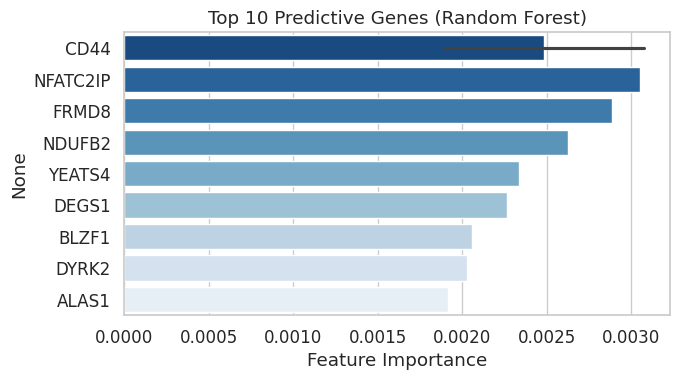

In [ ]:
# 把 probe ID 換成 gene symbol
top10_named = top10.copy()
top10_named.index = top10_genes['Gene Symbol'].values

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=top10_named.values, y=top10_named.index, ax=ax, palette='Blues_r')
ax.set_title('Top 10 Predictive Genes (Random Forest)')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.show()

## Next Steps

You've now:
- Made a publication-quality heatmap with sample annotations
- Used PCA to visualize high-dimensional biological data
- Trained an ML classifier and evaluated it honestly with AUC-ROC
- Identified biologically interpretable features

**Phase 1 milestone complete.** Head to `../phase2_tour/` to try all four bio-AI areas and pick your focus.

# Phase 1 複習筆記 — GSE2034 乳癌基因表現分析

## 1. 資料載入與標籤提取

**重點：** GSE2034 的復發標籤在 `characteristics_ch1` 欄位，格式為 `'bone relapses (1=yes, 0=no): 0'`，不在 sample title 裡。

```python
chars = gsm.metadata.get('characteristics_ch1', [''])[0]
label = int(chars.split(': ')[-1])
```

**資料概況：**
- 22283 基因 × 286 樣本
- Label 分佈：0（無復發）217 人，1（有復發）69 人 → 約 75:25
- 不平衡是正常的，臨床資料集本來就是少數人復發

---

## 2. Heatmap（Clustermap）

**目的：** 視覺化基因表現模式，看有無復發的病人是否自然分群。

**關鍵步驟：**

1. **選 top 50 最高變異基因**
   - 變異數高 = 這個基因在不同病人之間差異大 = 比較有資訊量
   ```python
   gene_var = expr.var(axis=1)  # 對每個基因算 286 個樣本的變異數
   top_genes = gene_var.nlargest(50).index
   ```

2. **Z-score 標準化**
   - 目的：不同基因絕對值差很多，標準化後才能在同一張圖比較
   - 公式：(值 − 平均) ÷ 標準差，對每個基因分別做
   ```python
   from scipy.stats import zscore
   expr_z = expr_top.apply(zscore, axis=1)
   ```

3. **Clustermap 參數：**
   - `col_colors`：樣本的顏色標注（紅=復發，藍=無復發）
   - `cmap='RdBu_r'`：高表現→紅色，低表現→藍色（`_r` 代表反轉）
   - 左側 dendrogram：基因的聚類（表現模式相似的基因靠在一起）
   - 上側 dendrogram：樣本的聚類

**結果：** 紅色樣本散落，無明顯分群 → 50 個基因不足以乾淨分開兩組，符合預期。

---

## 3. PCA

**目的：** 把 22283 維的基因表現壓縮成少數幾個主成分，保留最多變異資訊。

**關鍵概念：**
- PCA 找出資料變異最大的方向（PC1），再找第二大的（PC2）…
- 軸標籤上的 `% variance` = 這個 PC 保留了多少原始資料的變異量
- 2D 圖只能用 PC1 和 PC2

**決定保留幾個 PC：用 Scree Plot**
```python
pca_full = PCA(n_components=50)
pca_full.fit(X_scaled)
plt.plot(range(1, 51), pca_full.explained_variance_ratio_ * 100, marker='o')
```
曲線變平（手肘）的地方就是合理的截止點。本資料集約在第 9 個 PC。

**為什麼只 scale X 不 scale y？**
- X 是連續數值，不同基因範圍差很多，需要標準化
- y 是類別（0/1），標準化沒有意義

---

## 4. Train/Test Split

```python
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.25,    # 75% 訓練，25% 測試
    random_state=42,   # 固定隨機種子，結果可重現
    stratify=y         # 確保兩組的復發比例跟原始資料一樣
)
```

- `test_size=0.25`：慣例，樣本少時可用 0.2
- `random_state=42`：數字本身不重要，重點是讓別人能重現你的結果
- `stratify=y`：避免測試集復發比例偏差，確保評估公平

---

## 5. Random Forest 分類

**Random Forest 是什麼：**
- 單一決策樹 = 一連串 if/else 判斷
- Random Forest = 建立很多棵樹，每棵用隨機的基因子集訓練，最後多數決
- 類比：請 200 個專家各看部分報告，多數決比單一專家更穩定

**參數：**
- `n_estimators=200`：建 200 棵樹
- `n_jobs=-1`：用所有 CPU 核心平行計算

---

## 6. 模型評估：AUC-ROC

**AUC：**
- 0.5 = 跟隨機猜測一樣
- 1.0 = 完美分類
- 本資料集得到 **0.630**，對乳癌復發預測來說是典型結果

**ROC 曲線：**
- 橫軸：False Positive Rate（沒復發但誤判為復發的比例）
- 縱軸：True Positive Rate（有復發且正確預測的比例）
- 曲線越靠左上角越好，對角虛線 = 隨機猜測基準

---

## 7. Feature Importance 與生物驗證

**步驟：**
1. 從模型取出 feature importance
2. 用 platform annotation 把 probe ID 轉成基因名稱
3. 去 PubMed 驗證是否符合文獻

```python
platform = list(gse.gpls.values())[0]
annot = platform.table.set_index('ID')[['Gene Symbol', 'Gene Title']]
top10_genes = annot.loc[top10.index]
```

**結果：Top 10 基因中出現 CD44（兩次）**
- CD44 是乳癌幹細胞標記，CD44^high 細胞具有更強的轉移能力
- 大量文獻顯示與骨轉移和預後差有關
- 模型抓到有生物意義的基因 ✓

**probe ID 重複問題（同一基因有多個探針）：**
```python
# 重複的 gene symbol 加上 _1, _2 區分
seen = {}
for i, s in enumerate(symbols):
    if s in seen:
        symbols[seen[s]] = f'{s}_1'
        symbols[i] = f'{s}_2'
    else:
        seen[s] = i
```

---

## 總結

| 步驟 | 工具 | 目的 |
|------|------|------|
| 資料載入 | GEOparse | 取得基因表現矩陣和標籤 |
| Heatmap | seaborn clustermap | 視覺化基因表現模式 |
| PCA | sklearn PCA | 降維，找主要變異方向 |
| 分類 | Random Forest | 預測復發 |
| 評估 | AUC-ROC | 衡量模型分類能力 |
| 驗證 | PubMed | 確認結果有生物意義 |

**核心發現：** 光靠視覺化難以分開兩組（AUC 0.63），但模型成功識別出 CD44 等有生物意義的基因，符合乳癌文獻。